In [ ]:
# 1. Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(42)

## 1.1 (Opcional / si falla la descarga) Descarga manual robusta del dataset

`fetch_20newsgroups` descarga el dataset desde un mirror de Figshare. En Colab/Kaggle a veces ese mirror responde **`HTTP 403 Forbidden`** por bloqueo de bots / límite de descargas por IP compartida (es un problema del servidor, no de tu código).

**Si te sale ese error**, ejecuta esta celda antes de continuar: descarga el archivo manualmente (con cabeceras de navegador, y con una URL alterna de respaldo) y arma el caché en el mismo formato que espera scikit-learn. Una vez creado el caché, las siguientes veces `fetch_20newsgroups` lo carga directo sin volver a descargar nada.

Si `fetch_20newsgroups` te funcionó sin problema, puedes saltarte esta celda.

In [ ]:
import os, tarfile, pickle, codecs, shutil
import requests
from sklearn.datasets import get_data_home
from sklearn.datasets._base import _pkl_filepath, load_files

def preparar_cache_20newsgroups(data_home=None):
    data_home = get_data_home(data_home=data_home)
    cache_path = _pkl_filepath(data_home, "20news-bydate.pkz")
    twenty_home = os.path.join(data_home, "20news_home")

    if os.path.exists(cache_path):
        print("El caché ya existe, no hace falta descargar de nuevo:", cache_path)
        return

    os.makedirs(twenty_home, exist_ok=True)
    archive_path = os.path.join(twenty_home, "20news-bydate.tar.gz")

    # Intentamos varias fuentes por si una está bloqueada/caída
    urls_a_intentar = [
        "https://ndownloader.figshare.com/files/5975967",
        "http://qwone.com/~jason/20Newsgroups/20news-bydate.tar.gz",
    ]

    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
            "(KHTML, like Gecko) Chrome/124.0 Safari/537.36"
        )
    }

    descargado = False
    for url in urls_a_intentar:
        try:
            print(f"Intentando descargar desde: {url}")
            r = requests.get(url, headers=headers, timeout=60, stream=True)
            r.raise_for_status()
            with open(archive_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
            descargado = True
            print("Descarga exitosa desde:", url)
            break
        except Exception as e:
            print(f"  Falló ({url}): {e}")

    if not descargado:
        raise RuntimeError(
            "No se pudo descargar el dataset desde ninguna de las fuentes. "
            "Intenta de nuevo en unos minutos (puede ser un bloqueo temporal)."
        )

    train_path = os.path.join(twenty_home, "20news-bydate-train")
    test_path = os.path.join(twenty_home, "20news-bydate-test")

    print("Descomprimiendo...")
    with tarfile.open(archive_path, "r:gz") as tf:
        tf.extractall(path=twenty_home)

    print("Construyendo el caché (esto puede tardar un poco)...")
    cache = dict(
        train=load_files(train_path, encoding="latin1"),
        test=load_files(test_path, encoding="latin1"),
    )
    compressed_content = codecs.encode(pickle.dumps(cache), "zlib_codec")
    with open(cache_path, "wb") as f:
        f.write(compressed_content)

    shutil.rmtree(twenty_home)
    print("Listo. Caché guardado en:", cache_path)

# Solo ejecuta la descarga manual si el caché todavía no existe
preparar_cache_20newsgroups()

Intentando descargar desde: https://ndownloader.figshare.com/files/5975967
Descarga exitosa desde: https://ndownloader.figshare.com/files/5975967
Descomprimiendo...


/tmp/ipykernel_668/366743874.py:57: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(path=twenty_home)


Construyendo el caché (esto puede tardar un poco)...
Listo. Caché guardado en: /root/scikit_learn_data/20news-bydate_py3.pkz


## 2. Cargar el dataset

Usamos un subconjunto de categorías bien diferenciadas para que el clustering sea interpretable y rápido de ejecutar. (Se puede usar `categories=None` para cargar las 20 categorías completas).

In [ ]:
categories = [
    'alt.atheism',
    'comp.graphics',
    'sci.med',
    'sci.space',
    'rec.sport.baseball',
    'talk.politics.mideast',
    'soc.religion.christian',
]

newsgroups = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),  # evita que el modelo "haga trampa" con metadatos
    random_state=42
)

X_text = newsgroups.data
y_true = newsgroups.target
target_names = newsgroups.target_names

print(f"Número de documentos: {len(X_text)}")
print(f"Categorías: {target_names}")

Número de documentos: 4011
Categorías: ['alt.atheism', 'comp.graphics', 'rec.sport.baseball', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.mideast']


## 3. Vectorización de texto (TF-IDF)

Convertimos el texto en una representación numérica ponderando por frecuencia de término e inversa de frecuencia de documento.

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    min_df=5,
    max_df=0.5
)

X_tfidf = vectorizer.fit_transform(X_text)
print("Dimensiones TF-IDF:", X_tfidf.shape)

Dimensiones TF-IDF: (4011, 5000)


## 4. Reducción de dimensionalidad (LSA / TruncatedSVD)

La matriz TF-IDF es muy dispersa y de alta dimensión, lo cual perjudica a `AgglomerativeClustering` (especialmente con linkage `ward`, que asume distancia euclidiana). Reducimos a 100 componentes (Latent Semantic Analysis) antes de aplicar el clustering.

In [ ]:
svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X_tfidf)

print("Varianza explicada acumulada:", round(svd.explained_variance_ratio_.sum(), 3))

Varianza explicada acumulada: 0.188


## 5. Clustering jerárquico probando distintos criterios de *linkage*

Probamos tres criterios: `ward`, `complete` y `average`, y comparamos usando:
- **ARI** (Adjusted Rand Index): compara los clusters contra las categorías reales.
- **NMI** (Normalized Mutual Information): otra métrica de concordancia con las etiquetas reales.
- **Silhouette Score**: mide qué tan bien separados/compactos están los clusters (sin usar las etiquetas reales).

In [ ]:
n_clusters = len(categories)
linkage_methods = ['ward', 'complete', 'average']

results = {}
labels_by_method = {}

for method in linkage_methods:
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage=method)
    labels = model.fit_predict(X_reduced)
    labels_by_method[method] = labels

    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    sil = silhouette_score(X_reduced, labels)

    results[method] = {'ARI': ari, 'NMI': nmi, 'Silhouette': sil}
    print(f"Linkage = {method:10s} | ARI = {ari:.3f} | NMI = {nmi:.3f} | Silhouette = {sil:.3f}")

results_df = pd.DataFrame(results).T
results_df

Linkage = ward       | ARI = 0.121 | NMI = 0.311 | Silhouette = 0.063
Linkage = complete   | ARI = 0.001 | NMI = 0.045 | Silhouette = 0.186
Linkage = average    | ARI = 0.001 | NMI = 0.012 | Silhouette = 0.307


,ARI,NMI,Silhouette
ward,0.120914,0.311370,0.062721
complete,0.001405,0.045147,0.185714
average,0.000583,0.012333,0.307391


## 6. Dendrograma del mejor método

Seleccionamos automáticamente el método de linkage con mayor ARI (mayor concordancia con las categorías reales) y graficamos su dendrograma.

Mejor método de linkage según ARI: 'ward'


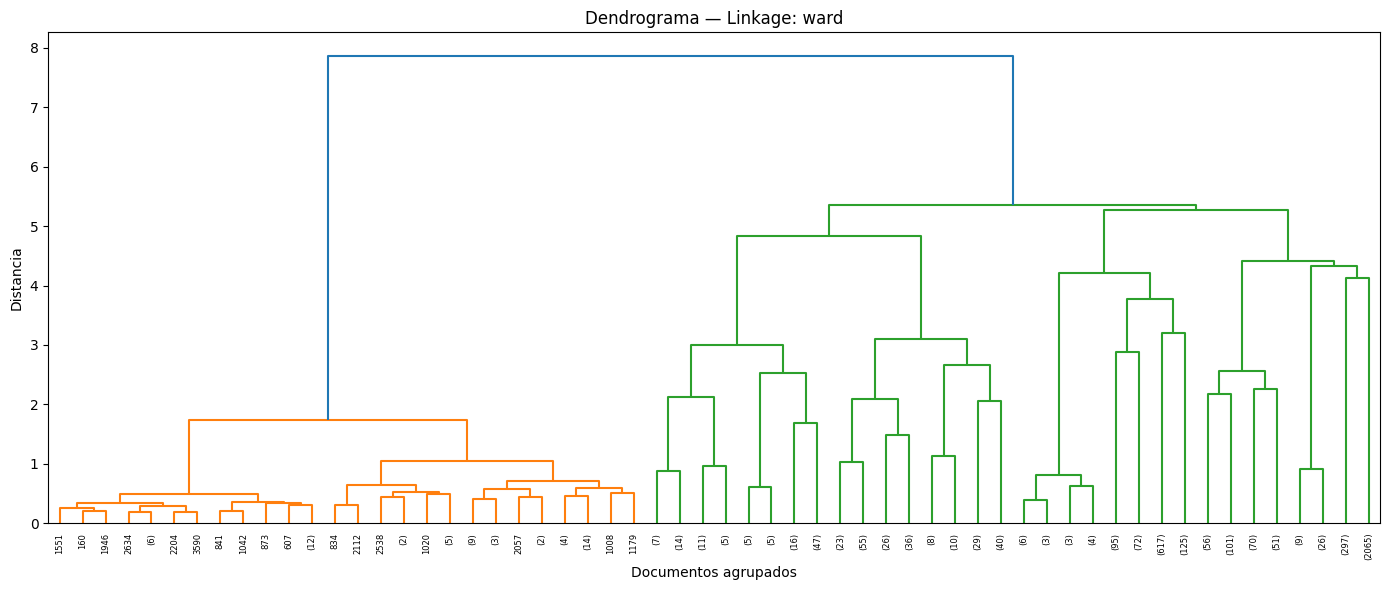

In [ ]:
best_method = results_df['ARI'].idxmax()
print(f"Mejor método de linkage según ARI: '{best_method}'")

Z = linkage(X_reduced, method=best_method)

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='level', p=5)
plt.title(f"Dendrograma — Linkage: {best_method}")
plt.xlabel("Documentos agrupados")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

## 7. Comparación cluster vs. categoría real

Una tabla de contingencia (crosstab) muestra qué tan bien cada cluster corresponde a una categoría real del dataset.

In [ ]:
best_labels = labels_by_method[best_method]

crosstab = pd.crosstab(
    pd.Series(y_true).map(lambda i: target_names[i]),
    pd.Series(best_labels),
    rownames=['Categoría real'],
    colnames=['Cluster asignado']
)
crosstab

Cluster asignado,0,1,2,3,4,5,6
Categoría real,,,,,,,
alt.atheism,285,188,5,0,1,1,0
comp.graphics,17,565,0,0,0,2,0
rec.sport.baseball,30,281,15,0,0,271,0
sci.med,67,416,0,74,0,2,35
sci.space,53,537,0,0,1,2,0
soc.religion.christian,424,167,7,0,1,0,0
talk.politics.mideast,49,208,200,0,107,0,0
